# Exercises XP: Guided Student Notebook

This guided notebook follows the **content on the platform**. Some cells are **prefilled** and must be **executed only**. Cells marked **To-Do** require your action. When a written answer is required, the **To-Do** appears inside a markdown cell. When code is required, the **To-Do** appears inside a code cell as comments.

**Learning points** appear when a concept is important for intuition or to help you learn new tricks/concepts related to other AI topics.


## Objectives

**What you will learn**  
- The fundamentals of deep learning and neural networks.
- How to build and train simple neural networks using TensorFlow or Keras.
- The concepts of forward and backward propagation.
- How to visualize and interpret model predictions.

**What you will create**  
- A simple perceptron-based decision system.
- A neural network for classifying handwritten digits from the MNIST dataset.
- A forward propagation calculation for predicting house prices.
- A Python implementation of forward and backward propagation.
- Visualizations of predictions made by a neural network on the MNIST dataset.


## 🌟 Exercise 1: Small Quiz

**As stated in the instructions**  
- What is the key difference between traditional machine learning and deep learning?  
- How do artificial neural networks mimic the human brain?  
- Why does deep learning perform better on large datasets compared to traditional machine learning?  
- What are some challenges of deep learning, and how can they be addressed?  
- What is feature engineering, and why is it not needed in deep learning?  
- What role do hidden layers play in a deep learning model?  
- In an artificial neural network, what is the function of an activation function?

**Guidance**  
Answer in full sentences. Use concise definitions first, then add one concrete example for any two questions to demonstrate understanding.

**To-Do:** Write your answers below.


#Exercise 1 Answers

1. The difference between traditional machine learning and deep learning is feature extraction. Traditional ML requires manual feature engineering by human experts. Deep Learning preforms automatic feature extraction. The neural networks learn to discover useful representations and features directly from raw data without the need for manual human intervention.

2. Artificial Neural Networks (ANNs) mimic the human brain in three ways: structure, information processing, and learning. Neurons take the place of synapses, passing on information. Signals and weights are processed to see whether they pass specific thresholds. ANNs use gradient descent and backpropagration to adjust weights to minimize prediction errors much as the human brain adjusts its synpatic connections to deal with new information and learned experiences.

3. Deep Learning is better on large datasets for two main reasons: performance saturation and representation power. Traditional ML uses algorithms that plateau in performance once a certain amount of data is reached. Deep Learning has highly complex architecture requiring millions of parameters, which work well with huge datasets. Representation power is better with Deep Learning because it is able to take the huge amounts of data and extract diverse patterns that otherwise would not be detected by smaller, simpler human machine learning or the more straightforward and limited human brain.

4. Deep Learning's biggest challenges are high data requirements, overfitting, computational expense, and lack of interpretability. High data requirements can be addressed by using transfer learning and data augmentation techniques to artifically expand the size of datasets. Overfitting can be addressed by adding regularization techniques like dropout (random deactivation of neurons during training), weight decay (L2 regularization) and Early Stopping (stopping performance when validation performance starts to decline). Computational expense can be addressed by major investment in data centers along with use of GPUs/TPUs to increase computational power. Lack of interpretability can be addressed by using Explainable AI (XAI) to help visualize and communication importance in an easily understood human-friendly fashion.

5. Feature engineering is the process of using domain knowledge to extract/transform/select/combine raw data into informative variables (features) that help ML algorithms make better predictions. This requires human experts. Deep Learning does not require it as end-to-end representation learning lets it extract features automatically through the learning epochs the DP models undergo.

6. Hidden Layers in Deep Learning are the hierarchical learning feature where the AI model does computations and learns during its training and testing. Each layer does higher level analysis (narrowing down to smaller and smaller levels of analysis) until it gets to the end layer and produces a result/answer (mainly identification) of whatever it is analyzing, like with visual data.

7. Activation functions introduce non-linearity into a network. This matters because it helps neural networks learn and solve much more complex problems. Mathematical operations like ReLU, Sigmoid, and Tanh adjust weighted sums and allow for non-linear problem solving to occur using real world data.

## 🌟 Exercise 2: Building a Simple Perceptron Decision System

**As stated in the instructions**  
You will create a perceptron-based decision system to decide whether you should go outside based on two inputs:
- Temperature in °F
- Rainy where Yes is 1 and No is 0

Given parameters: Temperature weight 0.6, Rain weight 0.4, Bias 2. Compute the weighted sum
\[ \text{Weighted Sum} = 0.6\cdot \text{Temperature} + 0.4\cdot \text{Rain} + \text{Bias} \]
Apply a step activation:
- If Weighted Sum > 20, output 1
- If Weighted Sum \le 20, output 0

Evaluate:  
Case 1: Temperature 70°F, Rain 0  
Case 2: Temperature 50°F, Rain 1

**Guidance**  
Implement the weighted sum function yourself. Use a reusable step activation. Then compute the two cases and print the decision for each.

**Learning point**  
A perceptron implements a linear decision boundary. The bias shifts the threshold. Use step activation for simple binary rules. Prefer differentiable activations when training with gradient descent.

![image.png](https://github.com/user-attachments/assets/3c4f3261-164d-4039-8e1c-aff2db7162dd)


In [1]:
# PREFILLED: just execute
from typing import Tuple

W_TEMP = 0.6
W_RAIN = 0.4
BIAS   = 2.0

def step_activation(s: float, threshold: float = 20.0) -> int:
    """Return 1 if s > threshold else 0."""
    return 1 if s > threshold else 0


In [2]:
def weighted_sum(temperature_f: float, rain01: int) -> float:
    """Compute s = 0.6*Temperature + 0.4*Rain + Bias."""
    return W_TEMP * temperature_f + W_RAIN * rain01 + BIAS

# Compute decisions for the two cases and print them
case1 = (70, 0)  # Temperature=70, Rain=0
case2 = (50, 1)  # Temperature=50, Rain=1

s1 = weighted_sum(*case1)
s2 = weighted_sum(*case2)
y1 = step_activation(s1)
y2 = step_activation(s2)

print({"case1": {"sum": s1, "decision": y1}, "case2": {"sum": s2, "decision": y2}})

{'case1': {'sum': 44.0, 'decision': 1}, 'case2': {'sum': 32.4, 'decision': 1}}


Yes, the perceptron suggested going outside in both cases (outputting `1` for both Case 1 and Case 2).

### Explanation:
* **Threshold Rule:** The decision boundary rule states that if the **Weighted Sum > 20**, the output is `1` (Go Outside), otherwise it is `0` (Stay Inside).
* **Case 1 (70°F, No Rain):**
  $$\text{Weighted Sum} = (0.6 \times 70) + (0.4 \times 0) + 2.0 = 42.0 + 0 + 2.0 = 44.0$$
  Since $44.0 > 20$, the decision is `1`.
* **Case 2 (50°F, Rain):**
  $$\text{Weighted Sum} = (0.6 \times 50) + (0.4 \times 1) + 2.0 = 30.0 + 0.4 + 2.0 = 32.4$$
  Since $32.4 > 20$, the decision is `1`.

### Effect of Bias:
The bias of $+2.0$ shifts the entire weighted sum upwards, acting as an extra positive baseline. Because the temperature values (50°F and 70°F) are relatively high compared to the threshold of 20, both cases easily surpass the threshold regardless of the rain condition.

## 🌟 Exercise 3: Building a Simple Neural Network with TensorFlow or Keras

**As stated in the instructions**  
Build a classifier for MNIST with:
- One input layer
- One hidden layer with 128 neurons and ReLU activation
- One output layer with 10 neurons and softmax activation

Steps:
1. Import TensorFlow and needed modules from `tensorflow.keras`
2. Load the MNIST dataset
3. Normalize data by dividing by 255.0
4. One-hot encode the labels
5. Build a sequential model with Flatten, Dense(128, ReLU), Dense(10, softmax)
6. Compile with optimizer `adam`, loss `categorical_crossentropy`, metrics `accuracy`
7. Train and evaluate on the test set

**Guidance**  
You will execute prefilled boilerplate for imports and dataset loading. You will complete the one-hot encoding and the model specification, compile, train, and evaluate.

**Learning point**  
Normalization stabilizes optimization. One-hot encoding matches softmax outputs to target vectors. ReLU accelerates training by avoiding saturation, while softmax maps logits to a probability simplex.

![image.png](https://github.com/user-attachments/assets/61737b80-69cb-41a1-aea5-76092cd2a373)


In [3]:
# PREFILLED: just execute
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist

print("TensorFlow:", tf.__version__)

# Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize to [0,1]
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# Flatten will be added in the model; keep images as 28x28 for now
print("Train shape:", x_train.shape, "Test shape:", x_test.shape)


TensorFlow: 2.20.0
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape: (60000, 28, 28) Test shape: (10000, 28, 28)


In [4]:
# To-Do: one-hot encode labels y_train and y_test using to_categorical
# Hints: use to_categorical
y_train_oh = to_categorical(y_train, num_classes=10)
y_test_oh  = to_categorical(y_test, num_classes=10)

print("Labels one-hot:", y_train_oh.shape, y_test_oh.shape)

Labels one-hot: (60000, 10) (10000, 10)


In [5]:
# To-Do:  Build a sequential model with Flatten, Dense(128, ReLU), Dense(10, softmax)
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# To-Do: compile the model with adam, categorical_crossentropy, and accuracy
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [7]:
# To-Do: train then evaluate
history = model.fit(x_train, y_train_oh, epochs=5, batch_size=64, validation_split=0.1)
test_loss, test_acc = model.evaluate(x_test, y_test_oh, verbose=0)
print({"test_loss": float(test_loss), "test_acc": float(test_acc)})

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9092 - loss: 0.3205 - val_accuracy: 0.9583 - val_loss: 0.1544
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9575 - loss: 0.1478 - val_accuracy: 0.9677 - val_loss: 0.1121
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9693 - loss: 0.1040 - val_accuracy: 0.9733 - val_loss: 0.0949
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9771 - loss: 0.0787 - val_accuracy: 0.9748 - val_loss: 0.0849
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9816 - loss: 0.0625 - val_accuracy: 0.9775 - val_loss: 0.0775
{'test_loss': 0.08640328794717789, 'test_acc': 0.9745000004768372}


## 🌟 Exercise 4: Forward Propagation Calculation

**As stated in the instructions**  
Predict house prices given:
- Inputs: x₁ = 2000 square feet, x₂ = 3 bedrooms
- Weights: w₁ = 0.5, w₂ = 0.7
- Bias: b = 50,000
- Activation: ReLU

Compute z before activation, apply ReLU, and interpret the prediction.

**Guidance**  
Write scalar computations. Then reason about the role of the bias and ReLU on the output scale.

**Learning point**  
ReLU passes positive linear combinations unchanged and zeros out negatives. Bias sets the baseline prediction independent of inputs.
![](./figs/1.gif)

In [8]:
# To-Do: compute forward propagation for the given numbers
x1, x2 = 2000.0, 3.0
w1, w2 = 0.5, 0.7
b = 50000.0

# To-Do: compute z = x1*w1 + x2*w2 + b
z = x1*w1 + x2*w2 + b

# To-Do: apply ReLU
y = max(0.0, z) #Hint: ReLU acts like max functions and leaves only positive outputs

print({"z": z, "prediction": y})

{'z': 51002.1, 'prediction': 51002.1}


**Interpretation:**

The resulting prediction is **$51,002.10**, which represents the predicted house price.

* **Influence of Bias:** The bias ($b = 50,000.0$) sets a massive positive baseline price for any house. Even if the square footage and number of bedrooms were zero, the model would predict a baseline starting value of $50,000.00.
* **Influence of Input Scaling:** The weights scale the raw inputs directly. Because square footage ($x_1 = 2000$) is numerically much larger than the bedroom count ($x_2 = 3$), its contribution ($2000 \times 0.5 = 1000$) dominates the input features' portion of the price prediction compared to the bedrooms ($3 \times 0.7 = 2.1$). This demonstrates why feature scaling/normalization is vital in machine learning so that feature magnitudes don't disproportionately dominate the network's calculations.

## 🌟 Exercise 5 (optional): Implementing Forward and Backward Propagation in Python

**As stated in the enoncé**  
You will code a simple neural network that performs forward propagation and backpropagation for a regression problem predicting exam scores from study hours.

**Guidance**  
Run the prefilled code. Then modify the learning rate or initial weights and observe changes in the loss and updates.
Provide a short written explanation.

**Learning point**  
Gradient descent updates parameters in the direction of steepest loss reduction.
The learning rate controls step size. Too small slows learning. Too large risks divergence.


In [9]:
# PREFILLED: just execute
import numpy as np

# Initialize input data (features)
x = np.array([4, 80])  # 4 hours studied, previous test score: 80

# Initialize weights and bias
w = np.array([0.6, 0.3])  # Initial weights
b = 10  # Initial bias

# Forward Propagation
def forward_propagation(x, w, b):
    z = np.dot(x, w) + b  # Weighted sum
    return z  # Linear activation (No ReLU here, it's a regression task)

# Compute prediction
y_pred = forward_propagation(x, w, b)
y_true = 85  # Actual exam score

# Compute Loss (Mean Squared Error)
loss = 0.5 * (y_true - y_pred) ** 2

# Compute Gradients
grad_w = -(y_true - y_pred) * x  # Partial derivatives with respect to weights
grad_b = -(y_true - y_pred)  # Partial derivative with respect to bias

# Update Weights and Bias
learning_rate = 0.01
w_new = w - learning_rate * grad_w
b_new = b - learning_rate * grad_b

# Print Results
print("Initial Prediction:", y_pred)
print("Loss:", loss)
print("Updated Weights:", w_new)
print("Updated Bias:", b_new)


Initial Prediction: 36.4
Loss: 1180.98
Updated Weights: [ 2.544 39.18 ]
Updated Bias: 10.486


### Why Gradient Descent Reduces Error
Updating weights using gradient descent reduces prediction error because weights are adjusted in the opposite direction of the gradient of the loss function (the negative gradient). Since the gradient points in the direction of the steepest increase in error, moving in the opposite direction takes a step toward the local minimum of the loss surface, directly reducing the discrepancy between our model's predictions and actual targets.

### Impact of Adjusting Hyperparameters
* **Increasing the Learning Rate (e.g., from 0.01 to 0.1):** This leads to much larger steps being taken in each iteration. While this can potentially speed up convergence, setting it too high causes the updates to overshoot the minimum, leading to divergence where the loss increases or oscillates wildly.
* **Decreasing the Learning Rate (e.g., from 0.01 to 0.0001):** The parameter updates become tiny, resulting in a highly stable descent, but requiring many more iterations to reach the optimal weight configuration (exceedingly slow learning).
* **Altering Initial Weights:** Changing the starting weights alters the model's initial predictions, shifting the starting location on the loss surface. Starting closer to the optimal values reduces training time, while poor initialization can increase the time required to converge or cause the model to get stuck in poor local minima.

## 🌟 Exercise 6 (optional): Visualizing Predictions on MNIST

**As stated in the enoncé**  
Train a simple model on MNIST, then visualize predictions for some test images with predicted labels.

**Guidance**  
Reuse the model from Exercise 3 if still in memory. Otherwise re-run Exercise 3. Plot a grid of test images with predicted labels and optionally true labels.

**Learning point**  
Softmax outputs are probabilities over classes. Inspect the confidence values. Visual errors often indicate confusions between similar digits.

![image.png](https://github.com/user-attachments/assets/e00d3913-55d4-4b62-8f70-1216bcc2e4e4)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


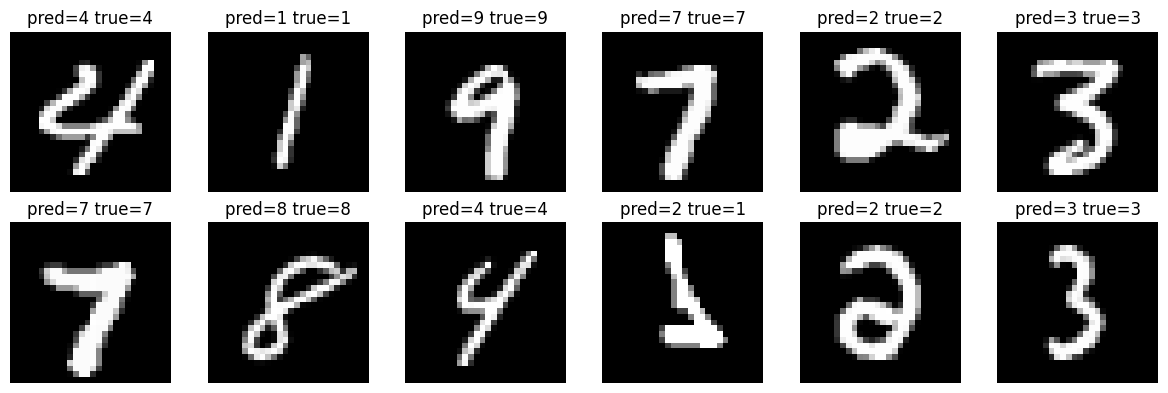

In [10]:
# To-Do: visualize a few predictions with matplotlib
import numpy as np
import matplotlib.pyplot as plt

# Ensure we have the model and x_test, y_test from Exercise 3
# To-Do: select N samples from x_test by using np.random.choice
num_samples = 12
idx = np.random.choice(len(x_test), size=num_samples, replace=False)
x_vis = x_test[idx]
y_true = y_test[idx]

# To-Do: get predictions
y_prob = model.predict(x_vis)
y_pred = np.argmax(y_prob, axis=1)

#plotting
cols = 6
rows = int(np.ceil(len(idx)/cols))
plt.figure(figsize=(12, 2*rows))
for i, k in enumerate(idx, 1):
    plt.subplot(rows, cols, i)
    plt.imshow(x_test[k], cmap="gray")
    plt.title(f"pred={y_pred[i-1]} true={y_true[i-1]}")
    plt.axis("off")
plt.tight_layout()
plt.show()